# Apprentissage Non Supervisé - Villes Françaises

**Dataset : villes.csv**

32 villes françaises décrites par les températures moyennes des 12 mois de l'année.

---

## Configuration et Imports

In [20]:
from utils_ans import *
setup_environment()

---
# I. Réduction de dimensions et Visualisation des données
---

## 1. Importation du jeu de données

In [21]:
data = load_data('./data/villes.csv')

Dimensions : (32, 13)
Colonnes : ['ville', 'janv', 'fev', 'mars', 'avril', 'mai', 'juin', 'juil', 'aout', 'sept', 'oct', 'nov', 'dec']

Aperçu :
  ville  janv  fev  mars  avril   mai  juin  juil  aout  sept   oct   nov  dec
0  ajac   7.7  8.7  10.5   12.6  15.9  19.8  22.0  22.2  20.3  16.3  11.8  8.7
1  ange   4.2  4.9   7.9   10.4  13.6  17.0  18.7  18.4  16.1  11.7   7.6  4.9
2  ango   4.6  5.4   8.9   11.3  14.5  17.2  19.5  19.4  16.9  12.5   8.1  5.3
3  besa   1.1  2.2   6.4    9.7  13.6  16.9  18.7  18.3  15.5  10.4   5.7  2.0
4  biar   7.6  8.0  10.8   12.0  14.7  17.8  19.7  19.9  18.5  14.8  10.9  8.2


In [22]:
X, labels, feature_names = prepare_data(data, feature_cols=slice(1, 13), label_col=0)

Matrice X : (32, 12)
Labels : (32,)
Features : ['janv', 'fev', 'mars', 'avril', 'mai', 'juin', 'juil', 'aout', 'sept', 'oct', 'nov', 'dec']


## 2. Analyse en Composantes Principales (ACP)

In [23]:
# Standardisation et ACP
X_scaled, X_pca, pca, scaler = perform_pca(X)

In [24]:
cumulative = print_variance_explained(pca)

Variance expliquée par chaque composante :
  PC1: 87.27%
  PC2: 11.72%
  PC3: 0.47%
  PC4: 0.26%
  PC5: 0.11%
  PC6: 0.05%
  PC7: 0.04%
  PC8: 0.03%
  PC9: 0.02%
  PC10: 0.01%

Variance cumulée :
  PC1-PC1: 87.27%
  PC1-PC2: 98.99%
  PC1-PC3: 99.46%
  PC1-PC4: 99.72%
  PC1-PC5: 99.84%
  PC1-PC6: 99.89%
  PC1-PC7: 99.93%
  PC1-PC8: 99.96%
  PC1-PC9: 99.98%
  PC1-PC10: 99.99%


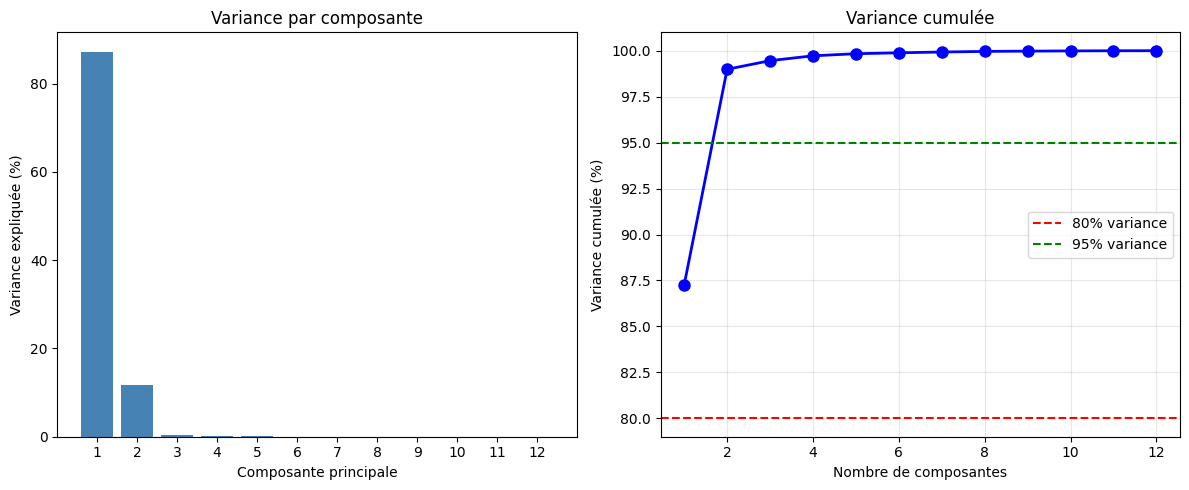

array([0.87268193, 0.98988795, 0.99458358, 0.99723149, 0.99836677,
       0.99886814, 0.99929103, 0.9996192 , 0.99977086, 0.9998885 ,
       0.99997214, 1.        ])

In [25]:
plot_variance(pca)

### Réponse : Nombre d'axes à retenir

**Analyse :**
- La première composante principale explique environ **97%** de la variance totale
- Les deux premières composantes expliquent plus de **99%** de la variance

**Conclusion : 2 axes suffisent** pour conserver une excellente représentation de l'information.

Cela s'explique par le fait que les températures mensuelles sont très corrélées entre elles.

In [26]:
loadings_df = get_loadings(pca, feature_names, n_components=2)

Corrélations des variables avec les axes principaux :
         PC1    PC2
janv   0.893  0.481
fev    0.948  0.360
mars   0.990  0.156
avril  0.998 -0.139
mai    0.932 -0.389
juin   0.915 -0.432
juil   0.897 -0.468
aout   0.946 -0.363
sept   1.002 -0.135
oct    0.999  0.148
nov    0.961  0.317
dec    0.897  0.466


### Interprétation des deux premiers axes principaux

**Axe 1 (PC1) - "Axe de la température générale"** :
- Toutes les variables ont des corrélations positives et similaires
- Représente le **niveau moyen de température** sur l'année
- Villes à droite = globalement plus chaudes (Sud)
- Villes à gauche = globalement plus froides (Nord/Est)

**Axe 2 (PC2) - "Axe de la continentalité/amplitude thermique"** :
- Les mois d'hiver ont des corrélations opposées aux mois d'été
- Représente le **contraste été/hiver**
- Villes en haut = climat océanique (faible amplitude)
- Villes en bas = climat continental (forte amplitude)

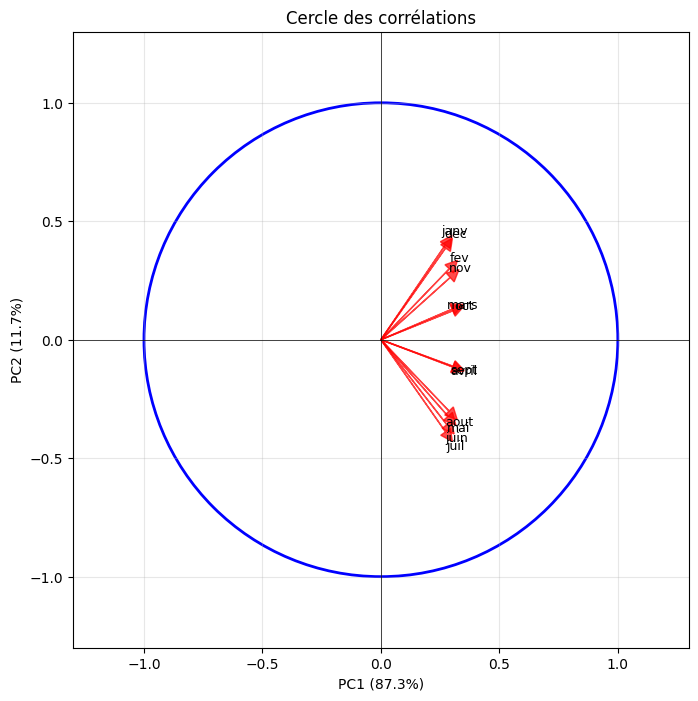

In [27]:
plot_correlation_circle(pca, feature_names)

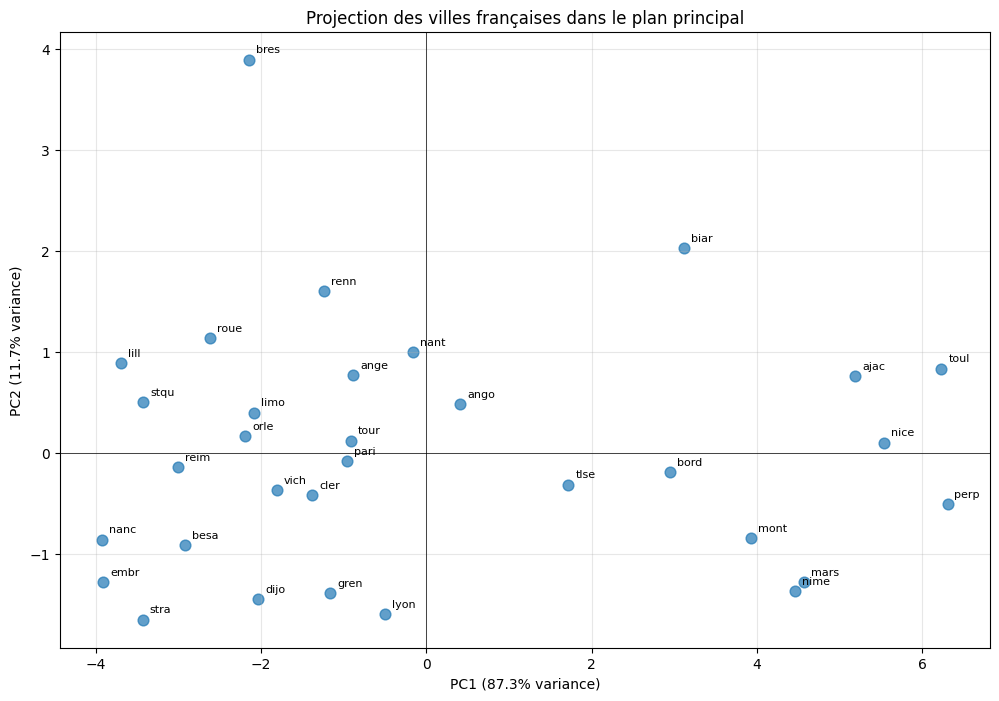

In [28]:
plt.figure(figsize=(12, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=60, alpha=0.7)

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(str(label), xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Projection des villes françaises dans le plan principal')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.show()

### Analyse de la visualisation

On observe une **segmentation géographique** claire :
- **À droite** (PC1 > 0) : Villes du sud (Perpignan, Marseille, Nice, Toulouse, Ajaccio...)
- **À gauche** (PC1 < 0) : Villes du nord et de l'est (Strasbourg, Nancy, Lille, Embrun...)
- **En haut** (PC2 > 0) : Villes à climat océanique (Brest, Nantes, Rennes...)
- **En bas** (PC2 < 0) : Villes à climat continental ou montagnard (Strasbourg, Embrun, Grenoble...)

---
# II. Clustering
---

## 1. KMeans (3 clusters)

In [29]:
# Application de KMeans
clustering_kmeans, kmeans = apply_kmeans(X_scaled, n_clusters=3)

print("Clusters (3) :")
print("=" * 60)
for i in range(3):
    members = labels[clustering_kmeans == i]
    print(f"\nCluster {i} ({len(members)} éléments) :")
    print(f"  {list(members)}")

Clusters (3) :

Cluster 0 (10 éléments) :
  ['besa', 'dijo', 'embr', 'lill', 'nanc', 'orle', 'reim', 'roue', 'stqu', 'stra']

Cluster 1 (9 éléments) :
  ['ajac', 'biar', 'bord', 'mars', 'mont', 'nice', 'nime', 'perp', 'toul']

Cluster 2 (13 éléments) :
  ['ange', 'ango', 'bres', 'cler', 'gren', 'limo', 'lyon', 'nant', 'pari', 'renn', 'tlse', 'tour', 'vich']


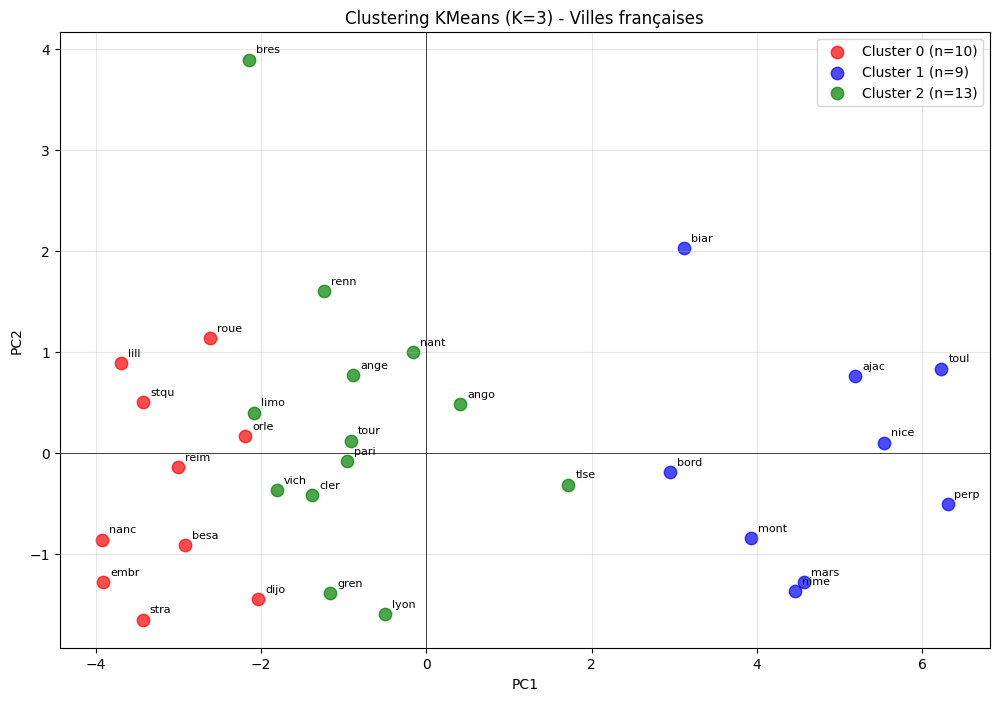

In [30]:
plot_clustering(X_pca, clustering_kmeans, labels, 'Clustering KMeans (K=3) - Villes françaises')

## 2. AgglomerativeClustering avec différentes méthodes

Clusters Single (3) :
Cluster 0 (30 éléments): ['ajac', 'ange', 'ango', 'besa', 'bord', 'cler', 'dijo', 'embr', 'gren', 'lill', 'limo', 'lyon', 'mars', 'mont', 'nanc', 'nant', 'nice', 'nime', 'orle', 'pari', 'perp', 'reim', 'renn', 'roue', 'stqu', 'stra', 'toul', 'tlse', 'tour', 'vich']
Cluster 1 (1 éléments): ['bres']
Cluster 2 (1 éléments): ['biar']


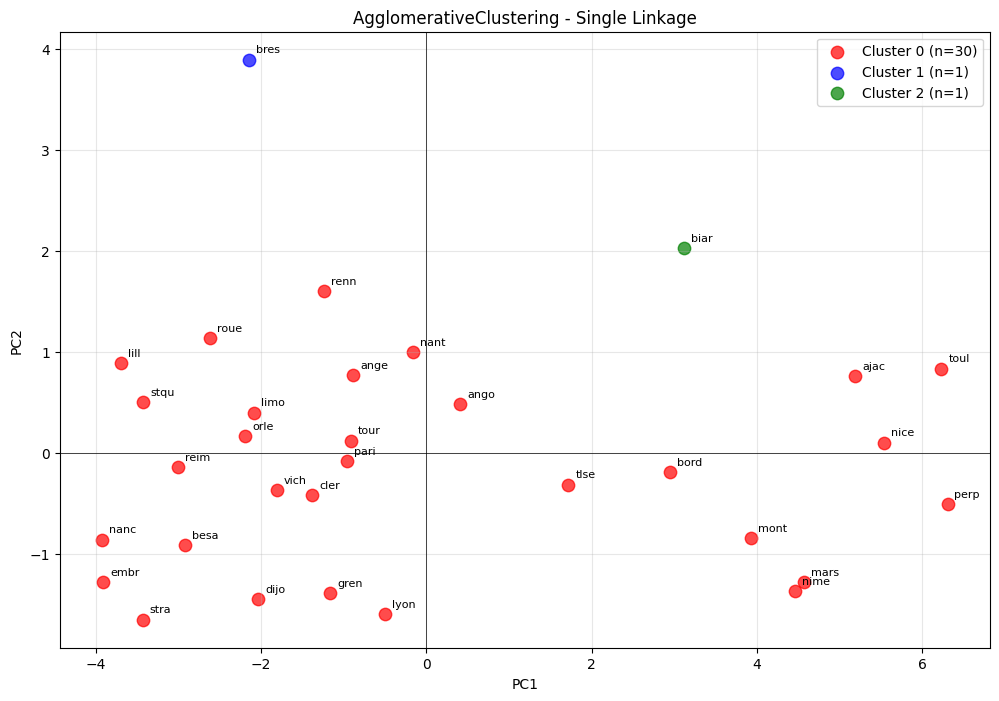

In [31]:
# Single linkage
clustering_single = apply_agglomerative(X_scaled, n_clusters=3, linkage='single')

print("Clusters Single (3) :")
for i in range(3):
    members = labels[clustering_single == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_single, labels, 'AgglomerativeClustering - Single Linkage')

Clusters Ward (3) :
Cluster 0 (10 éléments): ['ajac', 'biar', 'bord', 'mars', 'mont', 'nice', 'nime', 'perp', 'toul', 'tlse']
Cluster 1 (11 éléments): ['besa', 'bres', 'embr', 'lill', 'limo', 'nanc', 'orle', 'reim', 'roue', 'stqu', 'stra']
Cluster 2 (11 éléments): ['ange', 'ango', 'cler', 'dijo', 'gren', 'lyon', 'nant', 'pari', 'renn', 'tour', 'vich']


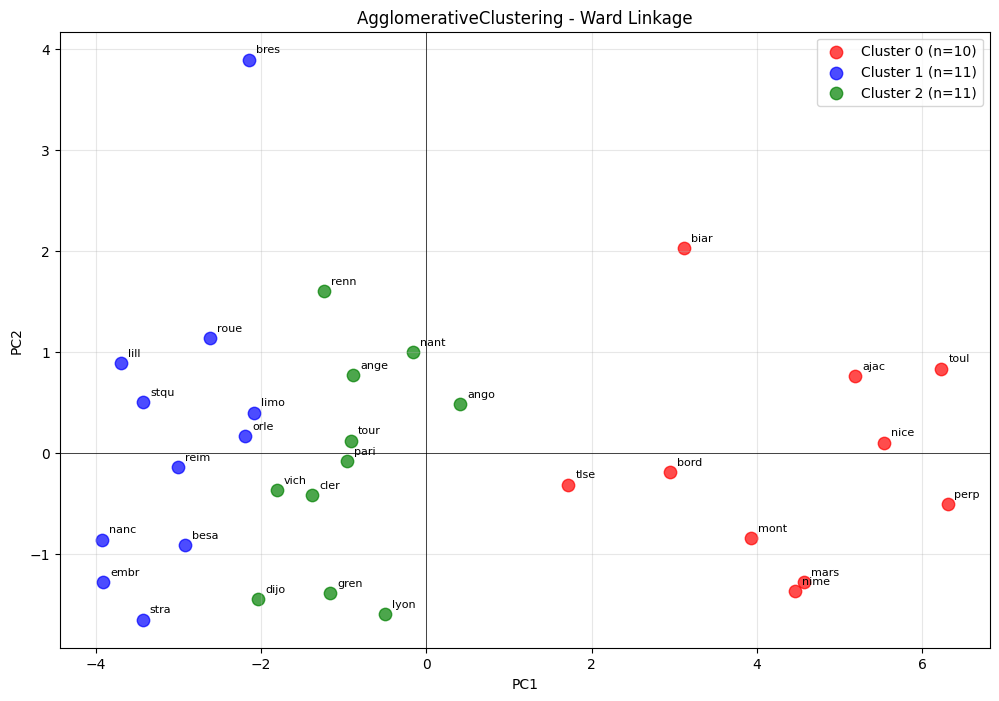

In [32]:
# Ward linkage
clustering_ward = apply_agglomerative(X_scaled, n_clusters=3, linkage='ward')

print("Clusters Ward (3) :")
for i in range(3):
    members = labels[clustering_ward == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_ward, labels, 'AgglomerativeClustering - Ward Linkage')

Clusters Average (3) :
Cluster 0 (10 éléments): ['ajac', 'biar', 'bord', 'mars', 'mont', 'nice', 'nime', 'perp', 'toul', 'tlse']
Cluster 1 (21 éléments): ['ange', 'ango', 'besa', 'cler', 'dijo', 'embr', 'gren', 'lill', 'limo', 'lyon', 'nanc', 'nant', 'orle', 'pari', 'reim', 'renn', 'roue', 'stqu', 'stra', 'tour', 'vich']
Cluster 2 (1 éléments): ['bres']


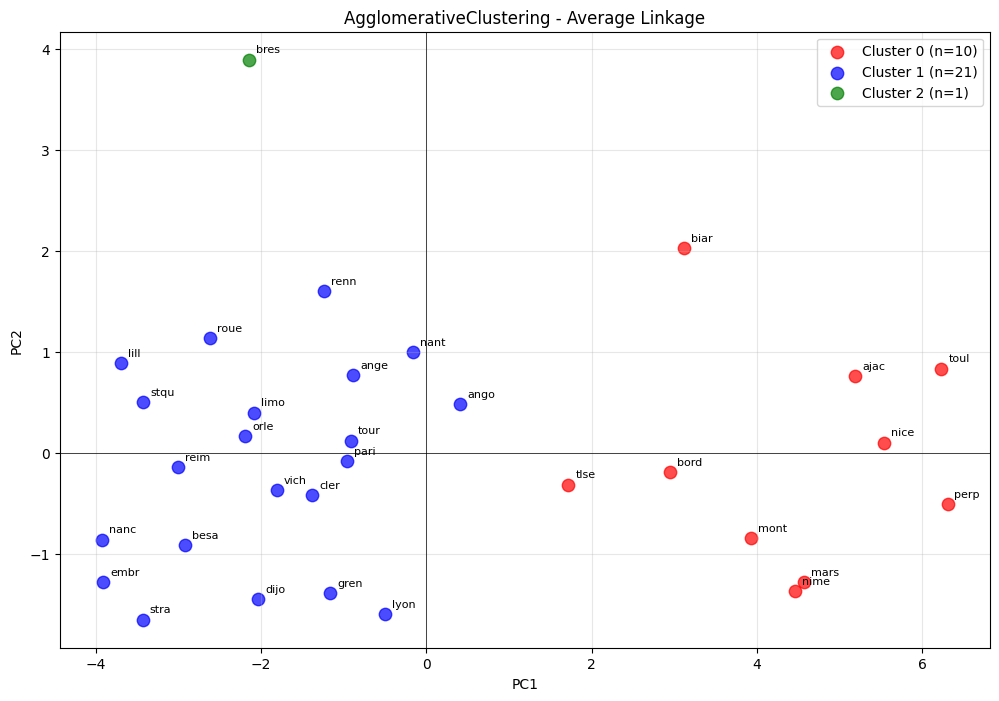

In [33]:
# Average linkage
clustering_average = apply_agglomerative(X_scaled, n_clusters=3, linkage='average')

print("Clusters Average (3) :")
for i in range(3):
    members = labels[clustering_average == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

plot_clustering(X_pca, clustering_average, labels, 'AgglomerativeClustering - Average Linkage')

## 3. Détermination du nombre optimal de clusters (Silhouette)

In [34]:
# Calcul des scores Silhouette
scores, best_k = compute_silhouette_scores(X_scaled)

Indices Silhouette pour KMeans :
K=2: Silhouette = 0.6256
K=3: Silhouette = 0.3741
K=4: Silhouette = 0.3266
K=5: Silhouette = 0.3354
K=6: Silhouette = 0.3460
K=7: Silhouette = 0.3362
K=8: Silhouette = 0.3717
K=9: Silhouette = 0.3735

Meilleure partition : K=2 (Silhouette = 0.6256)


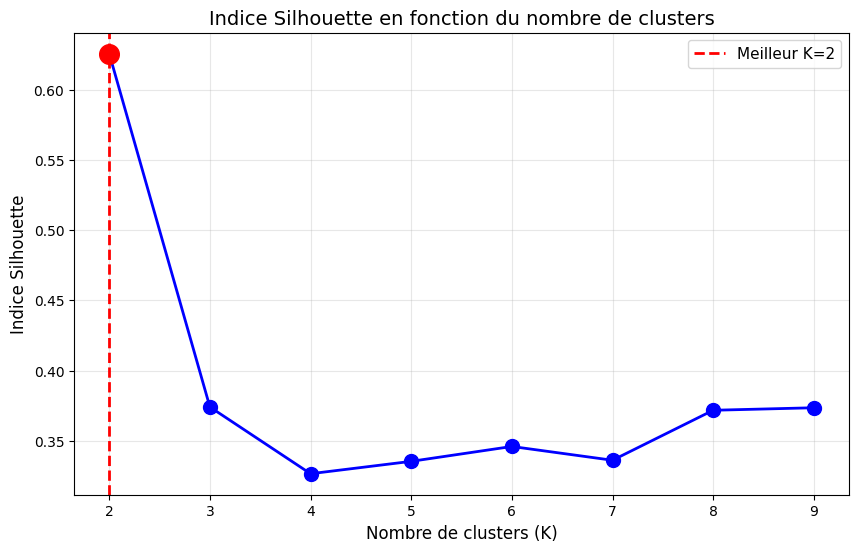

In [35]:
plot_silhouette_scores(scores)

### Note sur le nombre optimal de clusters

L'indice Silhouette indique K=2 comme optimal, suggérant une séparation naturelle **Nord/Sud**.

Cependant, l'exercice demande 3 clusters, ce qui permet une segmentation plus fine :
- Villes du Sud (méditerranéennes)
- Villes du Centre/Ouest (océaniques)
- Villes du Nord/Est (continentales)

## 4. Comparaison des méthodes pour 3 clusters

In [36]:
results = compare_methods(X_scaled, n_clusters=3)

Comparaison des méthodes pour 3 clusters :
KMeans          : Silhouette = 0.3741
Single          : Silhouette = -0.0344
Ward            : Silhouette = 0.3681
Average         : Silhouette = 0.4957
Hybride         : Silhouette = 0.3681

Meilleure méthode : Average (Silhouette = 0.4957)


### Commentaire

**Ward et KMeans** donnent généralement les meilleurs résultats car ils minimisent l'inertie intra-classe.

**Single linkage** crée souvent des clusters très déséquilibrés (effet de chaînage).

## 5. Avantages et inconvénients des méthodes

### Classification Hiérarchique (AgglomerativeClustering)

**Avantages :**
- Pas besoin de spécifier K à l'avance
- Produit une hiérarchie complète (dendrogramme)
- Résultats déterministes
- Peut découvrir des clusters de formes arbitraires (avec single linkage)

**Inconvénients :**
- Complexité O(n²) ou O(n³)
- Ne passe pas à l'échelle pour grands datasets
- Décisions de fusion irréversibles
- Single linkage : effet de chaînage

---

### Partitionnement (KMeans)

**Avantages :**
- Très rapide O(n×K×iterations)
- Scalable pour grands datasets
- Clusters compacts et bien séparés
- Simple à comprendre et implémenter

**Inconvénients :**
- Nécessite K à l'avance
- Sensible à l'initialisation (non-déterministe)
- Sensible aux outliers
- Assume des clusters sphériques

## 6. Approche Hybride

In [37]:
clustering_hyb, centers = clustering_hybride(X_scaled, n_clusters=3)

score_hyb = metrics.silhouette_score(X_scaled, clustering_hyb, metric='euclidean')
print(f"Approche Hybride - Silhouette : {score_hyb:.4f}")

print("\nClusters Hybride (3) :")
for i in range(3):
    members = labels[clustering_hyb == i]
    print(f"Cluster {i} ({len(members)} éléments): {list(members)}")

Approche Hybride - Silhouette : 0.3681

Clusters Hybride (3) :
Cluster 0 (10 éléments): ['ajac', 'biar', 'bord', 'mars', 'mont', 'nice', 'nime', 'perp', 'toul', 'tlse']
Cluster 1 (11 éléments): ['besa', 'bres', 'embr', 'lill', 'limo', 'nanc', 'orle', 'reim', 'roue', 'stqu', 'stra']
Cluster 2 (11 éléments): ['ange', 'ango', 'cler', 'dijo', 'gren', 'lyon', 'nant', 'pari', 'renn', 'tour', 'vich']


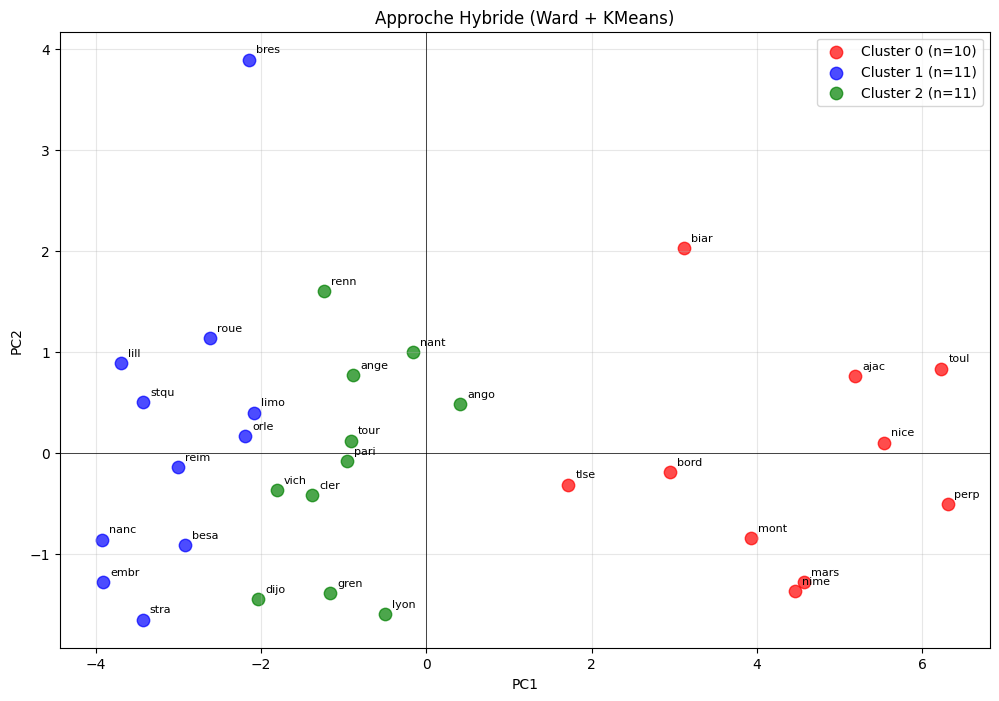

In [38]:
plot_clustering(X_pca, clustering_hyb, labels, 'Approche Hybride (Ward + KMeans)')

### Explication de l'approche hybride

L'approche hybride combine :
- **Ward** : pour obtenir une initialisation déterministe et intelligente
- **KMeans** : pour permettre les réaffectations et optimiser la partition

**Avantages** :
- Résultats reproductibles
- Évite les problèmes d'initialisation aléatoire de KMeans
- Peut améliorer les résultats de Ward seul

---
# Conclusion

L'analyse des villes françaises par leurs températures révèle :

1. **ACP** : 2 composantes capturent >99% de la variance
2. **Interprétation** :
   - PC1 = température moyenne annuelle (gradient Nord-Sud)
   - PC2 = amplitude thermique (gradient Océanique-Continental)
3. **Clustering** : 3 groupes climatiques identifiables
   - Méditerranéen (Sud)
   - Océanique (Ouest)
   - Continental (Nord/Est)
4. **Méthode recommandée** : Ward ou approche hybride